# Paragraph Overview

`Canvas.drawTextBlob` draws a single run of text on one line. Text that has to wrap to a
width, or mix styles within a block, needs the `textlayout` module, which shapes, breaks
and positions the lines.

Four objects are involved. A `FontCollection` resolves font families, a `TextStyle`
describes how a run of characters looks, a `ParagraphStyle` carries settings for the
block as a whole, and a `ParagraphBuilder` collects text and produces the paragraph.

In [1]:
import skia
from IPython.display import display, Image

font_collection = skia.textlayout.FontCollection()
font_collection.setDefaultFontManager(skia.FontMgr())
unicode = skia.Unicodes.ICU.Make()

def show(paragraph, width, height, x=20.0, y=20.0):
    surface = skia.Surface(width, height)
    canvas = surface.getCanvas()
    canvas.clear(skia.ColorWHITE)
    paragraph.paint(canvas, x, y)
    display(Image(data=surface.makeImageSnapshot().encodeToData()))

### Laying out a paragraph

The paragraph does nothing until `layout()` is called, which is what breaks the text into
lines. Call it before painting the paragraph or reading any of its metrics, and again
whenever the width changes.

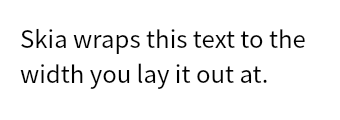

In [2]:
text_style = skia.textlayout.TextStyle()
text_style.setFontSize(24.0)
text_style.setColor(skia.ColorBLACK)

paragraph_style = skia.textlayout.ParagraphStyle()
paragraph_style.setTextStyle(text_style)

builder = skia.textlayout.ParagraphBuilder.make(paragraph_style, font_collection, unicode)
builder.addText("Skia wraps this text to the width you lay it out at.")
paragraph = builder.Build()
paragraph.layout(300.0)

show(paragraph, 340, 120)

### Mixing styles

The builder keeps a stack of text styles. Text added after `pushStyle()` uses the style
on top of the stack, and `pop()` returns to the one beneath it, so a single paragraph can
mix styles and still wrap as one block.

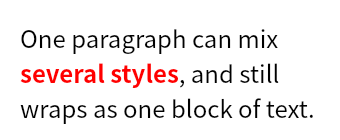

In [3]:
plain = skia.textlayout.TextStyle()
plain.setFontSize(24.0)
plain.setColor(skia.ColorBLACK)

accent = skia.textlayout.TextStyle()
accent.setFontSize(24.0)
accent.setColor(skia.ColorRED)
accent.setFontStyle(skia.FontStyle.Bold())

builder = skia.textlayout.ParagraphBuilder.make(
    skia.textlayout.ParagraphStyle(), font_collection, unicode)
builder.pushStyle(plain)
builder.addText("One paragraph can mix ")
builder.pop()
builder.pushStyle(accent)
builder.addText("several styles")
builder.pop()
builder.pushStyle(plain)
builder.addText(", and still wraps as one block of text.")
paragraph = builder.Build()
paragraph.layout(300.0)

show(paragraph, 340, 140)

### Line height

By default each line is as tall as the font says it should be. To set the line height
yourself, pass a multiple of the font size to `TextStyle.setHeight()` and enable it with
`TextStyle.setHeightOverride()`.

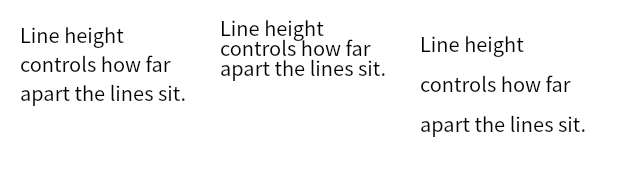

In [4]:
def laid_out(height_override, height):
    style = skia.textlayout.TextStyle()
    style.setFontSize(20.0)
    style.setColor(skia.ColorBLACK)
    style.setHeightOverride(height_override)
    style.setHeight(height)

    paragraph_style = skia.textlayout.ParagraphStyle()
    paragraph_style.setTextStyle(style)

    builder = skia.textlayout.ParagraphBuilder.make(paragraph_style, font_collection, unicode)
    builder.addText("Line height controls how far apart the lines sit.")
    paragraph = builder.Build()
    paragraph.layout(180.0)
    return paragraph

natural = laid_out(False, 2.0)   # setHeight ignored (the override is off)
tight   = laid_out(True, 1.0)    # exactly one font size per line
loose   = laid_out(True, 2.0)    # two font sizes per line

surface = skia.Surface(620, 190)
canvas = surface.getCanvas()
canvas.clear(skia.ColorWHITE)
natural.paint(canvas, 20.0, 20.0)
tight.paint(canvas, 220.0, 20.0)
loose.paint(canvas, 420.0, 20.0)
display(Image(data=surface.makeImageSnapshot().encodeToData()))

Left to right, the font's own line height, then `TextStyle.setHeight(1.0)` and
`TextStyle.setHeight(2.0)`. With the override on, the pitch is exactly the multiple of
the font size rather than whatever the font asks for.

Note the first of the three. `TextStyle.setHeight()` on its own does nothing. Without
`TextStyle.setHeightOverride(True)` the value is stored and ignored, and the paragraph
comes out at the font's natural height. With the override off, the same text comes out
at the same height whatever multiple is set.

In [5]:
for label, paragraph in (("natural", natural), ("height 1.0", tight), ("height 2.0", loose)):
    print(f"{label:12s} Height={paragraph.Height:6.2f}  ({paragraph.Height / 3:.2f} per line)")

# With the override off, setHeight is ignored. Both of these are the natural height.
print()
print("override off, setHeight(1.0):", laid_out(False, 1.0).Height)
print("override off, setHeight(2.0):", laid_out(False, 2.0).Height)

natural      Height= 87.00  (29.00 per line)
height 1.0   Height= 60.00  (20.00 per line)
height 2.0   Height=120.00  (40.00 per line)

override off, setHeight(1.0): 87.0
override off, setHeight(2.0): 87.0


### The strut

The line height from `TextStyle.setHeight()` is relative. Each run is measured against
its own font size, so a paragraph mixing 12 and 36 point text still comes out with lines
of different heights. The strut is the absolute version. It gives every line a minimum
height taken from a font of its own, so the lines keep a common rhythm whatever they
contain.

The name is borrowed from typesetting, where a strut is an invisible box of zero width
with a fixed height and depth that is dropped into a line to hold it open.

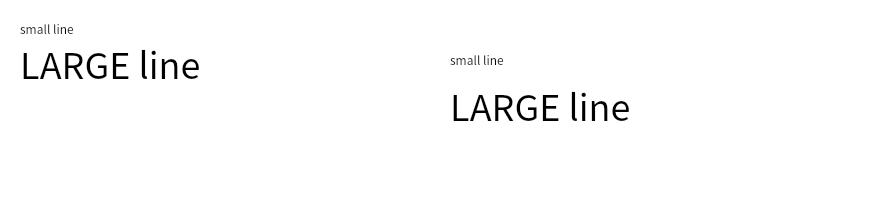

no strut    69.0
strut 4.0   112.0


In [6]:
def strutted(strut_height):
    paragraph_style = skia.textlayout.ParagraphStyle()
    if strut_height is not None:
        strut = skia.textlayout.StrutStyle()
        strut.setStrutEnabled(True)
        strut.setHeightOverride(True)
        strut.setHeight(strut_height)
        paragraph_style.setStrutStyle(strut)

    small = skia.textlayout.TextStyle()
    small.setFontSize(12.0)
    small.setColor(skia.ColorBLACK)
    large = skia.textlayout.TextStyle()
    large.setFontSize(36.0)
    large.setColor(skia.ColorBLACK)

    builder = skia.textlayout.ParagraphBuilder.make(paragraph_style, font_collection, unicode)
    builder.pushStyle(small)
    builder.addText("small line\n")
    builder.pop()
    builder.pushStyle(large)
    builder.addText("LARGE line")
    paragraph = builder.Build()
    paragraph.layout(400.0)
    return paragraph

surface = skia.Surface(880, 200)
canvas = surface.getCanvas()
canvas.clear(skia.ColorWHITE)
strutted(None).paint(canvas, 20.0, 20.0)
strutted(4.0).paint(canvas, 450.0, 20.0)
display(Image(data=surface.makeImageSnapshot().encodeToData()))

print("no strut   ", strutted(None).Height)
print("strut 4.0  ", strutted(4.0).Height)

Left, the two lines are 17 and 52 pixels tall. Right, under a strut of 4.0 they are 56
each. Every line comes out at the taller of its own height and the strut's, so the strut
is a floor rather than a setting, and `StrutStyle.setForceStrutHeight()` is what makes
it an exact height instead. The multiple applies to the strut's own font size, which is
14 unless `StrutStyle.setFontSize()` changes it, so 4.0 gives the 56 pixels here.

The strut is off by default. Turning it on applies the minimum at once, so text smaller
than the strut grows to meet it, which catches people who enabled the strut only to
reach `StrutStyle.setLeading()`.

In [7]:
def with_strut(text_size, strut_on):
    paragraph_style = skia.textlayout.ParagraphStyle()
    if strut_on:
        strut = skia.textlayout.StrutStyle()
        strut.setStrutEnabled(True)
        paragraph_style.setStrutStyle(strut)
    style = skia.textlayout.TextStyle()
    style.setFontSize(text_size)
    style.setColor(skia.ColorBLACK)
    paragraph_style.setTextStyle(style)
    builder = skia.textlayout.ParagraphBuilder.make(paragraph_style, font_collection, unicode)
    builder.pushStyle(style)
    builder.addText("x")
    paragraph = builder.Build()
    paragraph.layout(300.0)
    return paragraph

print("text size   strut off   strut on")
for size in (6.0, 8.0, 12.0, 20.0):
    print(f"{size:8.0f} pt {with_strut(size, False).Height:10.2f} {with_strut(size, True).Height:11.2f}")

text size   strut off   strut on
       6 pt       9.00       20.00
       8 pt      12.00       20.00
      12 pt      17.00       20.00
      20 pt      29.00       29.00


### Shifting text off the baseline

`TextStyle.setBaselineShift()` moves one run off the baseline the rest of the line sits
on, which is how superscripts and subscripts are made. Positive values move the text
down, so a superscript takes a negative shift, and the line box grows to keep the
shifted run inside it.

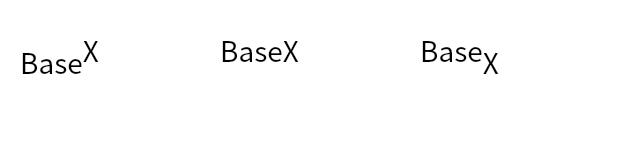

shift  -12.0   Height=53.0
shift   +0.0   Height=41.0
shift  +12.0   Height=53.0


In [8]:
def shifted(shift):
    def style(value):
        s = skia.textlayout.TextStyle()
        s.setFontSize(28.0)
        s.setColor(skia.ColorBLACK)
        s.setBaselineShift(value)
        return s

    builder = skia.textlayout.ParagraphBuilder.make(
        skia.textlayout.ParagraphStyle(), font_collection, unicode)
    builder.pushStyle(style(0.0))
    builder.addText("Base")
    builder.pop()
    builder.pushStyle(style(shift))
    builder.addText("X")
    paragraph = builder.Build()
    paragraph.layout(300.0)
    return paragraph

surface = skia.Surface(620, 150)
canvas = surface.getCanvas()
canvas.clear(skia.ColorWHITE)
for index, shift in enumerate((-12.0, 0.0, 12.0)):
    shifted(shift).paint(canvas, 20.0 + index * 200.0, 30.0)
display(Image(data=surface.makeImageSnapshot().encodeToData()))

for shift in (-12.0, 0.0, 12.0):
    print(f"shift {shift:+6.1f}   Height={shifted(shift).Height}")

### Measuring the result

After `layout()`, the paragraph reports what it produced. `Width` is the width passed to
`layout()`, not the width of the text, and `LongestLine` is how wide the text actually
came out. The two intrinsic widths are the bounds the text could take, the narrowest
width that never has to break a word and the width the whole text would need on one
line.

In [9]:
paragraph = laid_out(True, 1.5)
for name in ("Width", "LongestLine", "MinIntrinsicWidth", "MaxIntrinsicWidth",
             "Height", "ExceedMaxLines"):
    print(f"{name:18s}{getattr(paragraph, name)}")

# The intrinsic widths are bounds, not widths to lay out at: layout() compares strictly,
# so the text only fits on one line a fraction above MaxIntrinsicWidth.
widest = paragraph.MaxIntrinsicWidth
print()
paragraph.layout(widest)
print(f"layout({widest:.2f})   Height={paragraph.Height}")
paragraph.layout(widest + 1.0)
print(f"layout({widest + 1.0:.2f})   Height={paragraph.Height}")

Width             180.0
LongestLine       166.09979248046875
MinIntrinsicWidth 76.30000305175781
MaxIntrinsicWidth 429.44000244140625
Height            90.0
ExceedMaxLines    False

layout(429.44)   Height=60.0
layout(430.44)   Height=30.0


The same paragraph can be laid out again at any width and the metrics follow, which is
enough to fit text to a box by width. Fitting by font size needs a new paragraph each
time, because the text style is fixed once `Build()` is called.